#AI Job Market Salary Trends (Global, 2020–2026)


##Problem Definition

###What is the dataset about?
This dataset contains 6,823 AI and data-related job postings collected globally between 2020 and 2026.

It includes salary (in USD), job title, role category, experience level, employment type, region, remote work type, company size, industry, required AI tools, year-over-year demand change, and AI disruption risk.

Notably, records from **2020–2023** are based on real job postings and salary surveys, while **2024–2026** records are trend-based projections, explicitly flagged in the data through the data_note column.

Dataset Source : https://www.kaggle.com/datasets/hussnainmamoon1/ai-job-market-trends-and-salaries-20202026


###What main questions will you explore?



1. How have AI/data job salaries changed globally from 2020 through 2026?

2. Which roles, experience levels, and regions command the highest salaries — and where are the largest pay gaps?
How do remote/hybrid/on-site work type and company size relate to salary and job demand?

3. Which roles carry the highest AI disruption risk, and does that risk relate to salary or required tools?

4. Does the story change when real historical data (2020–2023) is separated from extrapolated projections (2024–2026)?

### What insights do you expect to uncover?

I expect salaries to rise with experience level and to be highest in regions with a higher cost of living, such as North America.

I also expect specialized AI roles (e.g., NLP/LLM, AI Research) to command higher salaries than more general data roles, and remote positions to show different salary patterns than on-site roles.

Since part of the dataset is projected rather than observed, I also expect the 2024–2026 trend to look "smoother" or more idealized than the real 2020–2023 data — which is itself a finding worth highlighting rather than ignoring.

#1- Data Loading & Structur

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")



#1- Data Understanding
---

In [69]:
df = pd.read_csv('/content/ai_job_market_salary_global_2020_2026_.csv')
df.head()

,job_id,posting_date,work_year,job_title,job_title_canonical,ai_role_category,experience_level,employment_type,salary_usd,salary_currency,...,employee_residence,remote_type,company_size,industry,ai_tools_required,yoy_demand_change,high_demand,ai_disruption_risk,data_source,data_note
0,JOB-00001,06/01/23,2023,Principal Data Scientist,Senior Data Scientist,Data Science,Senior,Full-Time,85847,EUR,...,Spain,Remote,Large (250+),Technology,"R, Python, SAS, Tableau",7%,False,Medium,ai-jobs.net salary survey,real
1,JOB-00002,13/07/23,2023,ML Engineer,Machine Learning Engineer,Machine Learning,Mid Level,Contract,30000,USD,...,United States,Remote,Small (<50),Technology,"Python, LightGBM, CatBoost, Optuna",25%,True,Low,ai-jobs.net salary survey,real
2,JOB-00003,10/05/23,2023,ML Engineer,Machine Learning Engineer,Machine Learning,Mid Level,Contract,25500,USD,...,United States,Remote,Small (<50),Technology,"Python, Spark MLlib, Databricks, MLflow",25%,True,Low,ai-jobs.net salary survey,real
3,JOB-00004,18/10/23,2023,Data Scientist,Data Scientist,Data Science,Senior,Full-Time,175000,USD,...,Canada,Remote,Medium (50-250),Technology,"Python, Polars, DuckDB, Plotly",7%,False,Medium,ai-jobs.net salary survey,real
4,JOB-00005,26/01/23,2023,Data Scientist,Data Scientist,Data Science,Senior,Full-Time,120000,USD,...,Canada,Remote,Medium (50-250),Technology,"Python, Scikit-learn, SQL, Power BI",7%,False,Medium,ai-jobs.net salary survey,real


In [4]:
df.tail()

,job_id,posting_date,work_year,job_title,job_title_canonical,ai_role_category,experience_level,employment_type,salary_usd,salary_currency,...,employee_residence,remote_type,company_size,industry,ai_tools_required,yoy_demand_change,high_demand,ai_disruption_risk,data_source,data_note
6916,JOB-06917,11/02/26,2026,AI Product Manager,AI Product Manager,Leadership,Mid Level,Full-Time,180565,USD,...,United States,Hybrid,Small (<50),Technology,"Python, SQL, Power BI, Confluence",6%,False,Medium,trend-extrapolated (WEF/SO/Lightcast 2026),extrapolated
6917,JOB-06918,24/05/26,2026,AI Engineer,AI Engineer,AI Research,Mid Level,Full-Time,162484,USD,...,United States,Hybrid,Large (250+),E-Commerce,"Python, PyTorch, Triton, CUDA",26%,True,Low,trend-extrapolated (WEF/SO/Lightcast 2026),extrapolated
6918,JOB-06919,09/03/26,2026,Retrieval Engineer,Retrieval Engineer,NLP / LLM,Senior,Full-Time,216414,USD,...,United States,On-site,Medium (50-250),Finance,"Python, Prompt Engineering, GPT-4, Claude API",41%,True,Low,trend-extrapolated (WEF/SO/Lightcast 2026),extrapolated
6919,JOB-06920,22/06/26,2026,Prompt Engineer,Prompt Engineer,NLP / LLM,Senior,Full-Time,166411,AUD,...,Australia,Hybrid,Medium (50-250),Technology,"Python, Transformers, BERT, NLTK",41%,True,Medium,trend-extrapolated (WEF/SO/Lightcast 2026),extrapolated
6920,JOB-06921,25/01/26,2026,LLMOps Engineer,LLMOps Engineer,MLOps / AI Infra,Entry Level,Full-Time,142666,AUD,...,Australia,Remote,Small (<50),Technology,"Python, Grafana, Prometheus, FastAPI",31%,True,Low,trend-extrapolated (WEF/SO/Lightcast 2026),extrapolated


In [5]:
df.columns.tolist()

['job_id',
 'posting_date',
 'work_year',
 'job_title',
 'job_title_canonical',
 'ai_role_category',
 'experience_level',
 'employment_type',
 'salary_usd',
 'salary_currency',
 'salary_basis',
 'salary_band',
 'company_location',
 'region',
 'employee_residence',
 'remote_type',
 'company_size',
 'industry',
 'ai_tools_required',
 'yoy_demand_change',
 'high_demand',
 'ai_disruption_risk',
 'data_source',
 'data_note']

In [6]:
df.describe()

,work_year
count,6921.000000
mean,2023.060396
std,1.761205
min,2020.000000
25%,2022.000000
50%,2023.000000
75%,2024.000000
max,2026.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6921 entries, 0 to 6920
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               6921 non-null   object
 1   posting_date         6921 non-null   object
 2   work_year            6921 non-null   int64 
 3   job_title            6921 non-null   object
 4   job_title_canonical  6921 non-null   object
 5   ai_role_category     6921 non-null   object
 6   experience_level     6921 non-null   object
 7   employment_type      6921 non-null   object
 8   salary_usd           6921 non-null   object
 9   salary_currency      6921 non-null   object
 10  salary_basis         6921 non-null   object
 11  salary_band          6921 non-null   object
 12  company_location     6921 non-null   object
 13  region               6921 non-null   object
 14  employee_residence   6921 non-null   object
 15  remote_type          6921 non-null   object
 16  compan

In [7]:
df.shape

(6921, 24)

In [8]:
df.size

166104

In [8]:
df.isnull().sum()

,0
job_id,0
posting_date,0
work_year,0
job_title,0
job_title_canonical,0
ai_role_category,0
experience_level,0
employment_type,0
salary_usd,0
salary_currency,0


---

---
#2- Data Cleaning



In [9]:
df.isnull().sum()

,0
job_id,0
posting_date,0
work_year,0
job_title,0
job_title_canonical,0
ai_role_category,0
experience_level,0
employment_type,0
salary_usd,0
salary_currency,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()
df.shape

(6921, 24)

## Handeling Data Types

### - Cleaning 'posting_date'

In [17]:
#converting posting dates from category to date/time
df['posting_date'] = pd.to_datetime(df['posting_date'],format='%d/%m/%y', errors='coerce')
print(f'posting_date Head : \n{df['posting_date'].head()}')
print()

print(f'Checking null values : \n{df['posting_date'].isnull().sum()}')
print()

print(f'column Data information :\n{df['posting_date'].info()}')

posting_date Head : 
0   2023-01-06
1   2023-07-13
2   2023-05-10
3   2023-10-18
4   2023-01-26
Name: posting_date, dtype: datetime64[ns]

Checking null values : 
0

<class 'pandas.core.series.Series'>
RangeIndex: 6921 entries, 0 to 6920
Series name: posting_date
Non-Null Count  Dtype         
--------------  -----         
6921 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 54.2 KB
column Data information :
None


### - Cleaning 'salary_usd'





In [18]:
df['salary_usd'] = pd.to_numeric(df['salary_usd'], errors='coerce')
df['salary_usd'].isnull().sum()

np.int64(98)

In [19]:
bad_rows = pd.to_numeric(df['salary_usd'], errors='coerce').isnull()
df[bad_rows]

,job_id,posting_date,work_year,job_title,job_title_canonical,ai_role_category,experience_level,employment_type,salary_usd,salary_currency,...,employee_residence,remote_type,company_size,industry,ai_tools_required,yoy_demand_change,high_demand,ai_disruption_risk,data_source,data_note
3749,JOB-03750,2020-12-06,2020,"""Scientist I/II","Biology""","""Scientist I/II","Biology""",Other AI / Data,NaN,Full-Time,...,United States,North America,United States,On-site,"Small (<50), Biotech & Pharmaceuticals, Python...",5%,False,Medium,Glassdoor scraped (2020),real
3784,JOB-03785,2020-06-24,2020,"""Data Scientist","Office of Data Science""","""Data Scientist","Office of Data Science""",Data Science,NaN,Full-Time,...,United States,North America,United States,Hybrid,"Large (250+), Insurance Carriers, Python, Stat...",12%,True,Medium,Glassdoor scraped (2020),real
3804,JOB-03805,2020-08-23,2020,"""Director","Data Science""","""Director","Data Science""",Leadership,NaN,Full-Time,...,United States,North America,United States,Hybrid,"Large (250+), Wholesale, Python, Spark, Databr...",5%,False,Medium,Glassdoor scraped (2020),real
3835,JOB-03836,2020-10-25,2020,"""Data Scientist","Rice University""","""Data Scientist","Rice University""",Data Science,NaN,Full-Time,...,United States,North America,United States,Hybrid,"Large (250+), Education Training Services, Pyt...",12%,True,Medium,Glassdoor scraped (2020),real
3866,JOB-03867,2020-10-07,2020,"""Scientist 2","QC Viral Vector""","""Scientist 2","QC Viral Vector""",Other AI / Data,NaN,Full-Time,...,United States,North America,United States,On-site,"Large (250+), Biotech & Pharmaceuticals, Pytho...",8%,False,Medium,Glassdoor scraped (2020),real
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4458,JOB-04459,2020-05-28,2020,"""Associate Scientist","LC/MS Biologics""","""Associate Scientist","LC/MS Biologics""",Other AI / Data,NaN,Full-Time,...,United States,North America,United States,Hybrid,"Large (250+), Biotech & Pharmaceuticals, Pytho...",8%,False,Medium,Glassdoor scraped (2020),real
4459,JOB-04460,2020-09-15,2020,"""Research Scientist","Immunology - Cancer Biology""","""Research Scientist","Immunology - Cancer Biology""",Data Science,NaN,Full-Time,...,United States,North America,United States,On-site,"Medium (50-250), -1, Python, Statsmodels, Scip...",12%,True,Medium,Glassdoor scraped (2020),real
4465,JOB-04466,2020-03-09,2020,"""Principal","Data Science - Advanced Analytics""","""Principal","Data Science - Advanced Analytics""",Data Analytics,NaN,Full-Time,...,United States,North America,United States,Remote,"Large (250+), Biotech & Pharmaceuticals, SQL, ...",5%,False,High,Glassdoor scraped (2020),real
4466,JOB-04467,2020-02-07,2020,"""Sr Scientist","Immuno-Oncology - Oncology""","""Sr Scientist","Immuno-Oncology - Oncology""",Other AI / Data,NaN,Full-Time,...,United States,North America,United States,On-site,"Large (250+), Biotech & Pharmaceuticals, Pytho...",12%,True,Medium,Glassdoor scraped (2020),real


In [20]:
# remove the 98 corrupted rows
df = df[~bad_rows]
df.shape

(6823, 24)

In [21]:
df['salary_usd'].isnull().sum()

np.int64(0)

**After cleaning the 'salary_usd' column, there were 98 null values that used to be strings. I checked them and decided to remove them because they only represent 1.42% of the column data.**

In [22]:
df['salary_usd'].describe()

,salary_usd
count,6823.000000
mean,150726.129855
std,65375.820276
min,10000.000000
25%,104244.500000
50%,146251.000000
75%,195000.000000
max,450068.000000


### - Cleaning 'yoy_demand_change'
- indecates year-over-year demand on role

In [23]:
df['yoy_demand_change'] = df['yoy_demand_change'].str.replace('%', '')
df['yoy_demand_change'] = pd.to_numeric(df['yoy_demand_change'], errors='coerce')
df['yoy_demand_change'] = df['yoy_demand_change'] / 100
df['yoy_demand_change'].head()

,yoy_demand_change
0,0.07
1,0.25
2,0.25
3,0.07
4,0.07


##-Drop unnecessary columns


In [26]:
# job_id - just check it's unique (no analytical value)
df['job_id'].nunique() == len(df)


True

In [27]:
# job_title vs job_title_canonical - compare a few rows
df[['job_title', 'job_title_canonical']].head(10)

,job_title,job_title_canonical
0,Principal Data Scientist,Senior Data Scientist
1,ML Engineer,Machine Learning Engineer
2,ML Engineer,Machine Learning Engineer
3,Data Scientist,Data Scientist
4,Data Scientist,Data Scientist
5,Applied Scientist,Applied Scientist
6,Applied Scientist,Applied Scientist
7,Data Scientist,Data Scientist
8,Data Scientist,Data Scientist
9,Data Scientist,Data Scientist


In [28]:
# salary_currency - no longer needed since salary_usd already exists
df['salary_currency'].value_counts()

,count
salary_currency,
USD,5544
EUR,454
GBP,305
INR,183
CAD,153
AUD,60
CHF,31
JPY,27
BRL,21


In [25]:
df['salary_basis'].value_counts()

,count
salary_basis,
Annual (USD),6823


In [31]:

df[['salary_usd', 'salary_band']].head(10)

,salary_usd,salary_band
0,85847.0,$80K-$120K
1,30000.0,<$50K
2,25500.0,<$50K
3,175000.0,$120K-$180K
4,120000.0,$120K-$180K
5,222200.0,$180K-$250K
6,136000.0,$120K-$180K
7,219000.0,$180K-$250K
8,141000.0,$120K-$180K
9,147100.0,$120K-$180K


In [30]:
# company_location vs region - check overlap
df[['company_location', 'region']].drop_duplicates().head(15)

,company_location,region
0,Spain,Europe
1,United States,North America
3,Canada,North America
21,Germany,Europe
23,United Kingdom,Europe
39,Nigeria,Africa
41,India,Asia Pacific
80,Hong Kong,Asia Pacific
84,Netherlands,Europe
114,Switzerland,Europe


In [33]:
# data_source vs data_note - check overlap
df[['data_source', 'data_note']].drop_duplicates()

,data_source,data_note
0,ai-jobs.net salary survey,real
775,ai-jobs.net salary survey,2021: limited survey responses in source data
3733,Glassdoor scraped (2020),real
4471,trend-extrapolated (WEF/SO/Lightcast 2024),extrapolated
5271,trend-extrapolated (WEF/SO/Lightcast 2025),extrapolated
6071,trend-extrapolated (WEF/SO/Lightcast 2026),extrapolated


In [40]:
# employee_residence - check how often it differs from company_location
(df['employee_residence'] != df['company_location']).sum()

np.int64(92)

In [70]:
df = df.drop(columns=['job_id', 'job_title', 'salary_currency', 'salary_basis', 'data_source'])
df.columns.to_list()

['posting_date',
 'work_year',
 'job_title_canonical',
 'ai_role_category',
 'experience_level',
 'employment_type',
 'salary_usd',
 'salary_band',
 'company_location',
 'region',
 'employee_residence',
 'remote_type',
 'company_size',
 'industry',
 'ai_tools_required',
 'yoy_demand_change',
 'high_demand',
 'ai_disruption_risk',
 'data_note']

### COulmns To Drop
- **job_id**: unique identifier, no analytical value.
- **job_title**: raw/messy version — replaced by `job_title_canonical`.
- **salary_currency**: no longer needed since salary is already in USD.
- **salary_basis**: constant value ("Annual (USD)") for all rows — no variation.
- **data_source**: overlaps with `data_note`, which already flags real vs. projected data.

**Kept despite being derived/overlapping columns:**
- **salary_band**: pre-binned salary ranges are useful for dashboard filters
  and cleaner category-based charts, even though `salary_usd` has the exact value.
- **company_location**: gives country-level detail beyond what `region` provides,
  useful for more granular geographic analysis.
- **employee_residence**: kept for potential remote-work analysis (comparing
  where employees live vs. where the company is located).

In [42]:
#Checking data shape and column after dropping
df.shape

(6823, 19)

In [39]:
df.columns.to_list()


['posting_date',
 'work_year',
 'job_title_canonical',
 'ai_role_category',
 'experience_level',
 'employment_type',
 'salary_usd',
 'salary_band',
 'company_location',
 'region',
 'employee_residence',
 'remote_type',
 'company_size',
 'industry',
 'ai_tools_required',
 'yoy_demand_change',
 'high_demand',
 'ai_disruption_risk',
 'data_note']

In [45]:
#Renaming the job title col
df = df.rename(columns={'job_title_canonical': 'job_title'})
df.columns.to_list()

['posting_date',
 'work_year',
 'job_title',
 'ai_role_category',
 'experience_level',
 'employment_type',
 'salary_usd',
 'salary_band',
 'company_location',
 'region',
 'employee_residence',
 'remote_type',
 'company_size',
 'industry',
 'ai_tools_required',
 'yoy_demand_change',
 'high_demand',
 'ai_disruption_risk',
 'data_note']

In [46]:
# Saving clean Data
df.to_csv('ai_job_market_salary_global_2020_2026_clean.csv', index=False)

---

## EDA - Checking clean dataset


In [91]:
df_clean=pd.read_csv('/content/ai_job_market_salary_global_2020_2026_clean.csv')
df_clean.head()

,posting_date,work_year,job_title,ai_role_category,experience_level,employment_type,salary_usd,salary_band,company_location,region,employee_residence,remote_type,company_size,industry,ai_tools_required,yoy_demand_change,high_demand,ai_disruption_risk,data_note
0,2023-01-06,2023,Senior Data Scientist,Data Science,Senior,Full-Time,85847.0,$80K-$120K,Spain,Europe,Spain,Remote,Large (250+),Technology,"R, Python, SAS, Tableau",0.07,False,Medium,real
1,2023-07-13,2023,Machine Learning Engineer,Machine Learning,Mid Level,Contract,30000.0,<$50K,United States,North America,United States,Remote,Small (<50),Technology,"Python, LightGBM, CatBoost, Optuna",0.25,True,Low,real
2,2023-05-10,2023,Machine Learning Engineer,Machine Learning,Mid Level,Contract,25500.0,<$50K,United States,North America,United States,Remote,Small (<50),Technology,"Python, Spark MLlib, Databricks, MLflow",0.25,True,Low,real
3,2023-10-18,2023,Data Scientist,Data Science,Senior,Full-Time,175000.0,$120K-$180K,Canada,North America,Canada,Remote,Medium (50-250),Technology,"Python, Polars, DuckDB, Plotly",0.07,False,Medium,real
4,2023-01-26,2023,Data Scientist,Data Science,Senior,Full-Time,120000.0,$120K-$180K,Canada,North America,Canada,Remote,Medium (50-250),Technology,"Python, Scikit-learn, SQL, Power BI",0.07,False,Medium,real


In [92]:
df_clean.shape

(6823, 19)

In [93]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6823 entries, 0 to 6822
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   posting_date        6823 non-null   object 
 1   work_year           6823 non-null   int64  
 2   job_title           6823 non-null   object 
 3   ai_role_category    6823 non-null   object 
 4   experience_level    6823 non-null   object 
 5   employment_type     6823 non-null   object 
 6   salary_usd          6823 non-null   float64
 7   salary_band         6823 non-null   object 
 8   company_location    6823 non-null   object 
 9   region              6823 non-null   object 
 10  employee_residence  6823 non-null   object 
 11  remote_type         6823 non-null   object 
 12  company_size        6823 non-null   object 
 13  industry            6823 non-null   object 
 14  ai_tools_required   6823 non-null   object 
 15  yoy_demand_change   6823 non-null   float64
 16  high_d

####Numerical

In [94]:
#Numerical
df_clean[['salary_usd', 'yoy_demand_change', 'work_year']].describe()

,salary_usd,yoy_demand_change,work_year
count,6823.000000,6823.000000,6823.000000
mean,150726.129855,0.147239,2023.104353
std,65375.820276,0.118398,1.734913
min,10000.000000,-0.050000,2020.000000
25%,104244.500000,0.060000,2022.000000
50%,146251.000000,0.120000,2023.000000
75%,195000.000000,0.220000,2024.000000
max,450068.000000,0.450000,2026.000000


####Categorical

In [95]:
df_clean['ai_role_category'].value_counts()

,count
ai_role_category,
Data Science,1310
Data Engineering,1278
Data Analytics,1191
Other AI / Data,880
Machine Learning,729
Leadership,422
NLP / LLM,394
MLOps / AI Infra,325
AI Research,187


In [96]:
df_clean['experience_level'].value_counts()

,count
experience_level,
Senior,4164
Mid Level,1923
Entry Level,500
Executive,236


In [97]:
df_clean['employment_type'].value_counts()

,count
employment_type,
Full-Time,6637
Contract,92
Part-Time,60
Freelance,34


In [98]:
df_clean['region'].value_counts()

,count
region,
North America,5421
Europe,861
Asia Pacific,382
Middle East,51
Latin America,46
Other,45
Africa,17


In [80]:
df_clean['remote_type'].value_counts()

,count
remote_type,
On-site,3282
Remote,2374
Hybrid,1167


In [81]:
df_clean['company_size'].value_counts()

,count
company_size,
Medium (50-250),5102
Large (250+),1235
Small (<50),486


In [82]:
print(df_clean['industry'].value_counts())

industry
Technology                              5179
Finance                                  278
Healthcare                               234
E-Commerce                               137
Consulting                               110
                                        ... 
Trucking                                   1
Auctions & Galleries                       1
Beauty & Personal Accessories Stores       1
Accounting                                 1
Health, Beauty, & Fitness                  1
Name: count, Length: 68, dtype: int64


In [83]:
df_clean['ai_disruption_risk'].value_counts()

,count
ai_disruption_risk,
Medium,3917
Low,1670
High,1236


In [84]:
df_clean['data_note'].value_counts()

,count
data_note,
real,4149
extrapolated,2450
2021: limited survey responses in source data,224


In [85]:
df_clean.groupby('remote_type')['employee_residence'].nunique()

,employee_residence
remote_type,
Hybrid,52
On-site,46
Remote,54


In [103]:
df_clean['salary_band'].value_counts()

,count
salary_band,
$120K-$180K,2352
$180K-$250K,1745
$80K-$120K,1296
$50K-$80K,626
$250K+,478
<$50K,326


In [99]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6823 entries, 0 to 6822
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   posting_date        6823 non-null   object 
 1   work_year           6823 non-null   int64  
 2   job_title           6823 non-null   object 
 3   ai_role_category    6823 non-null   object 
 4   experience_level    6823 non-null   object 
 5   employment_type     6823 non-null   object 
 6   salary_usd          6823 non-null   float64
 7   salary_band         6823 non-null   object 
 8   company_location    6823 non-null   object 
 9   region              6823 non-null   object 
 10  employee_residence  6823 non-null   object 
 11  remote_type         6823 non-null   object 
 12  company_size        6823 non-null   object 
 13  industry            6823 non-null   object 
 14  ai_tools_required   6823 non-null   object 
 15  yoy_demand_change   6823 non-null   float64
 16  high_d

cleaning data type

In [102]:
df_clean['posting_date'] = pd.to_datetime(df['posting_date'])
df_clean.dtypes

,0
posting_date,datetime64[ns]
work_year,int64
job_title,object
ai_role_category,object
experience_level,object
employment_type,object
salary_usd,float64
salary_band,object
company_location,object
region,object


In [105]:
df_clean.shape

(6823, 19)

---

##EDA - Visualization

###Univariate

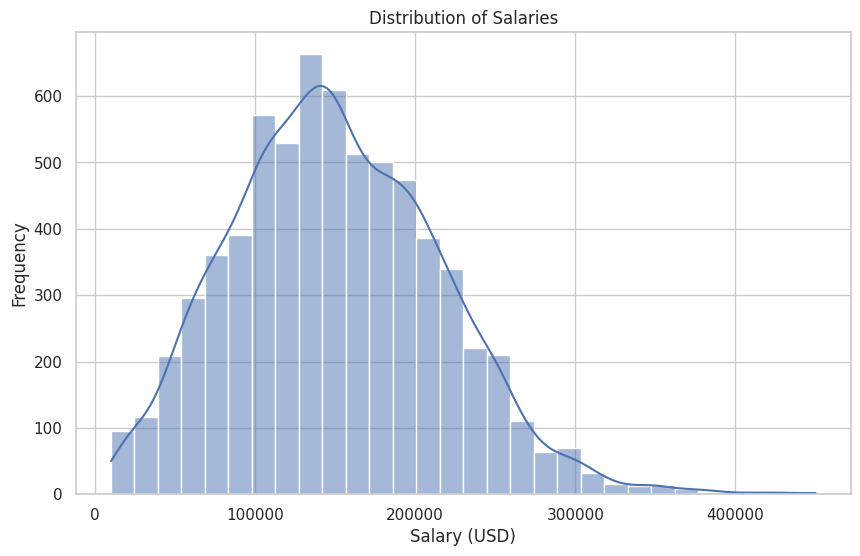

In [106]:
#A general understanding of salary distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['salary_usd'], bins=30, kde=True)
plt.title('Distribution of Salaries')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()

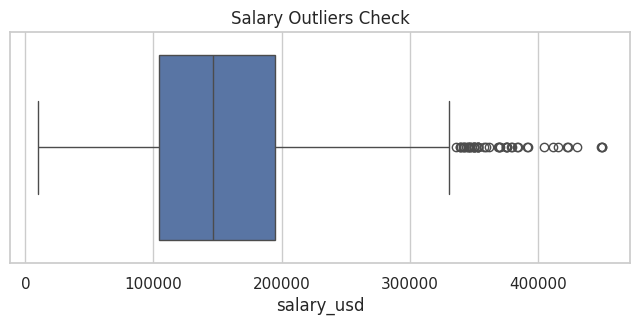

In [113]:
# outliers
plt.figure(figsize=(8,3))
sns.boxplot(x=df_clean['salary_usd'])
plt.title('Salary Outliers Check')
plt.show()

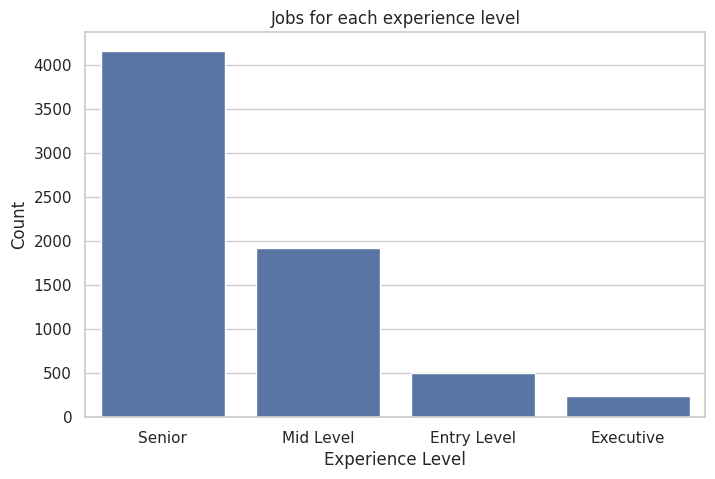

In [122]:

#Market composition (which segment is largest: Entry, Mid, or Senior?)
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x='experience_level')
plt.title('Jobs for each experience level')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.show()

###Bivariate/Multivariate

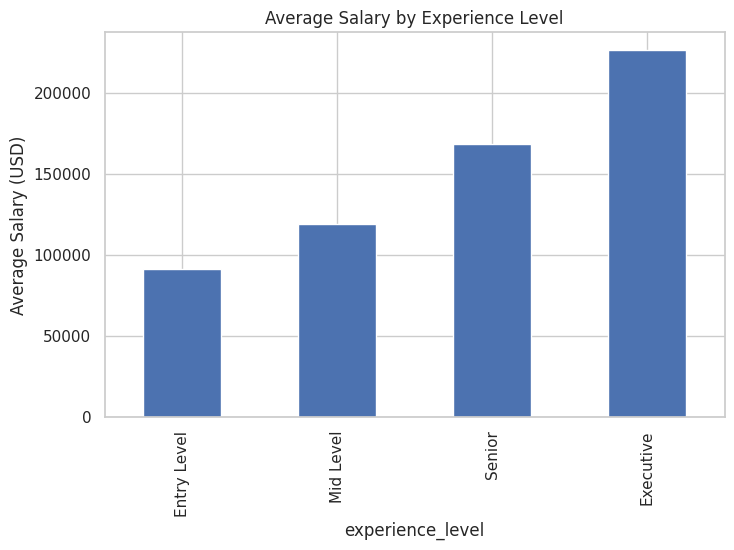

In [123]:
#Average salary by experience level
#Question 2 — Salary gap by experience
plt.figure(figsize=(8,5))
df_clean.groupby('experience_level')['salary_usd'].mean().sort_values().plot(kind='bar')
plt.title('Average Salary by Experience Level')
plt.ylabel('Average Salary (USD)')
plt.show()

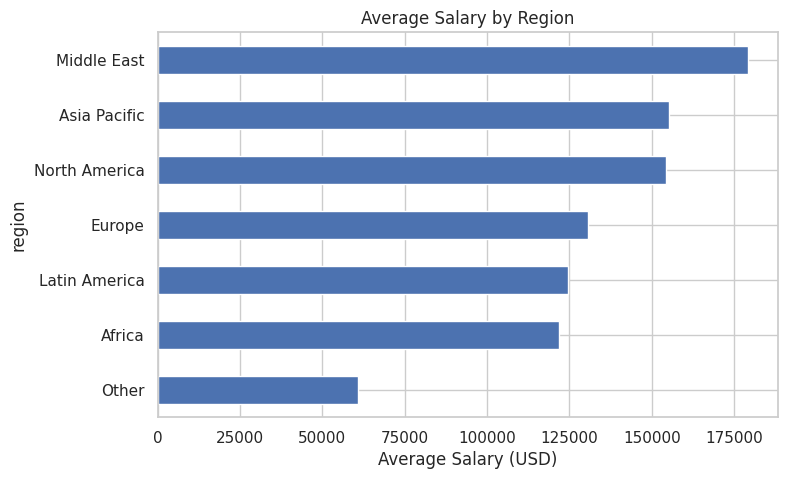

In [124]:
#Average Salary by Region
#Question 2 — Salary gap by region
plt.figure(figsize=(8,5))
df_clean.groupby('region')['salary_usd'].mean().sort_values().plot(kind='barh')
plt.title('Average Salary by Region')
plt.xlabel('Average Salary (USD)')
plt.show()

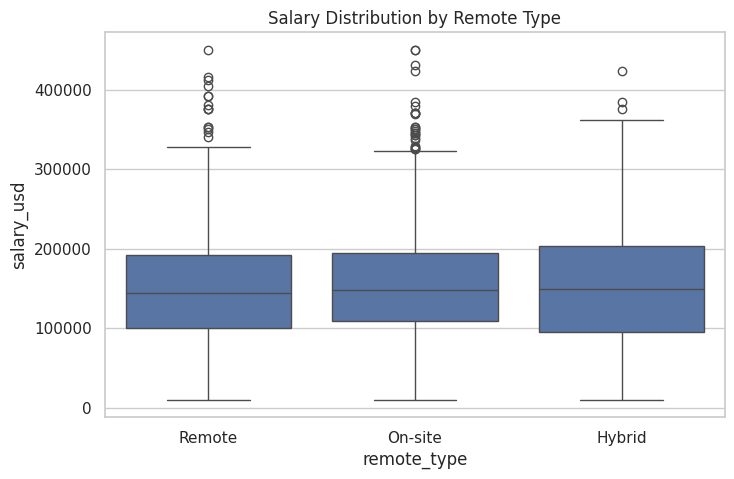

In [125]:
#Question 3 — The impact of the type of work on salary
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='remote_type', y='salary_usd')
plt.title('Salary Distribution by Remote Type')
plt.show()

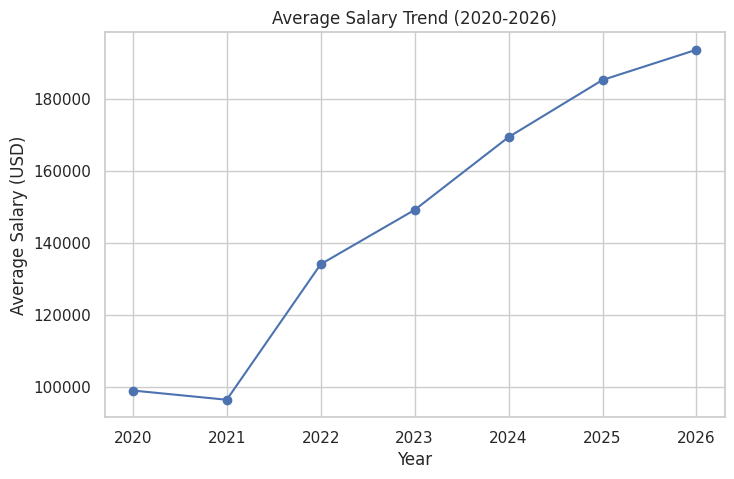

In [126]:
#Question 1 — Salary progression over time
plt.figure(figsize=(8,5))
df_clean.groupby('work_year')['salary_usd'].mean().plot(kind='line', marker='o')
plt.title('Average Salary Trend (2020-2026)')
plt.xlabel('Year')
plt.ylabel('Average Salary (USD)')
plt.show()

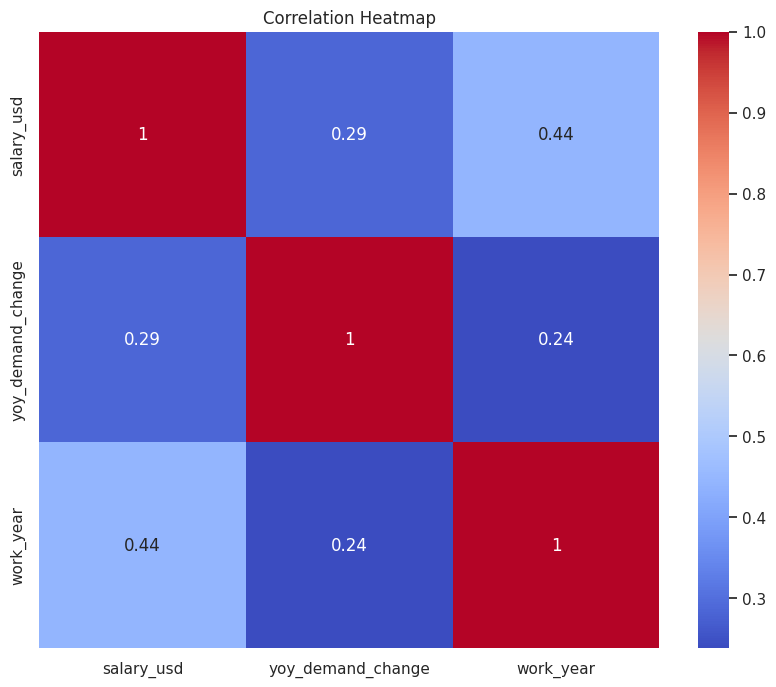

In [121]:
#Correlation between numerical columns
plt.figure(figsize=(10,8))
numeric_cols = df_clean[['salary_usd', 'yoy_demand_change', 'work_year']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

---


1. Real vs Extrapolated

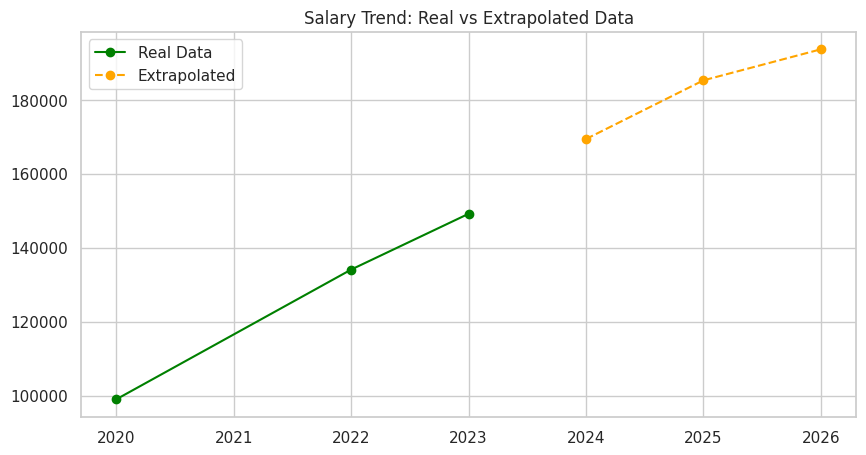

In [127]:
plt.figure(figsize=(10,5))

real = df_clean[df_clean['data_note']=='real'].groupby('work_year')['salary_usd'].mean()

extrap = df_clean[df_clean['data_note']=='extrapolated'].groupby('work_year')['salary_usd'].mean()

plt.plot(real.index, real.values, marker='o', label='Real Data', color='green')
plt.plot(extrap.index, extrap.values, marker='o', label='Extrapolated', color='orange', linestyle='--')
plt.legend()
plt.title('Salary Trend: Real vs Extrapolated Data')
plt.show()

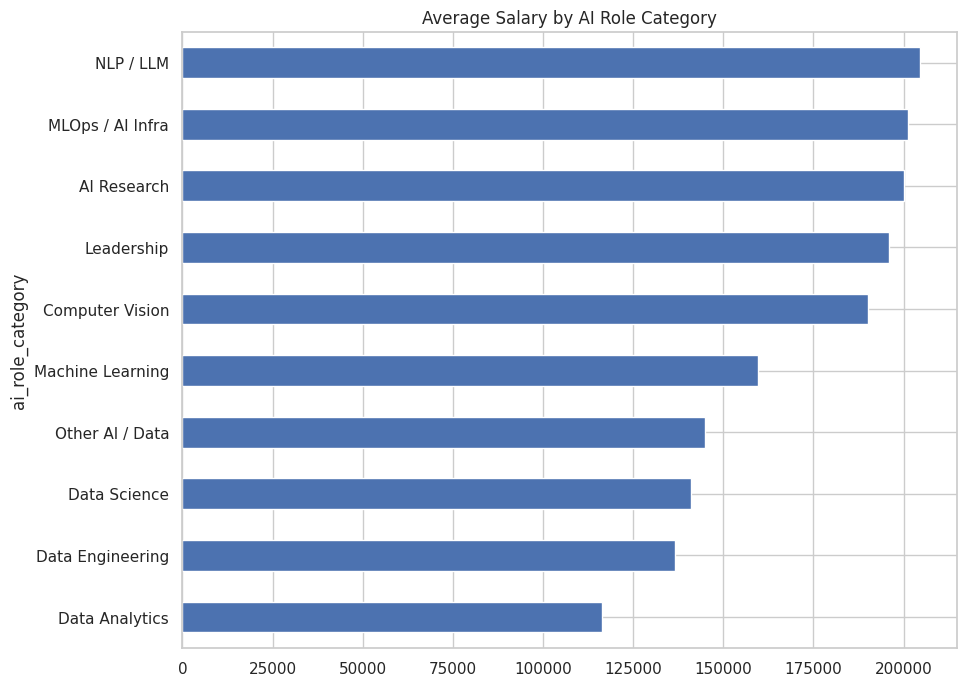

In [129]:
#Roles with the highest actual salaries
#(not just based on experience level)
plt.figure(figsize=(10,8))
df_clean.groupby('ai_role_category')['salary_usd'].mean().sort_values().plot(kind='barh')
plt.title('Average Salary by AI Role Category')
plt.show()

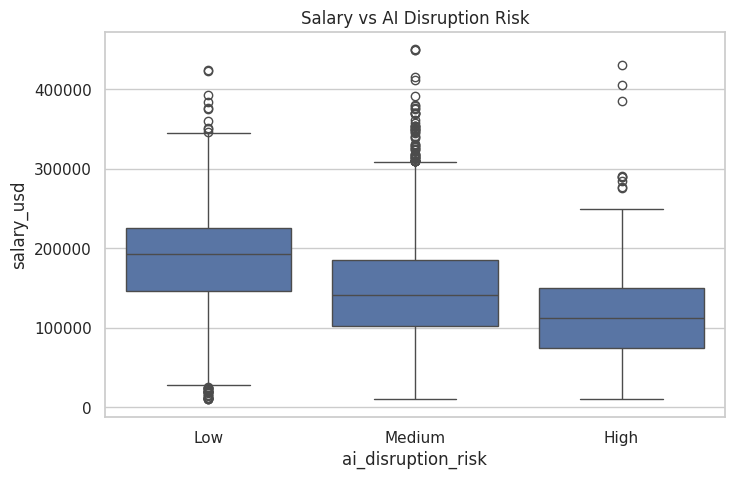

In [130]:
#Risks of AI Replacement vs. Salary
#Do roles at risk of replacement command lower or higher salaries?

plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='ai_disruption_risk', y='salary_usd', order=['Low','Medium','High'])
plt.title('Salary vs AI Disruption Risk')
plt.show()

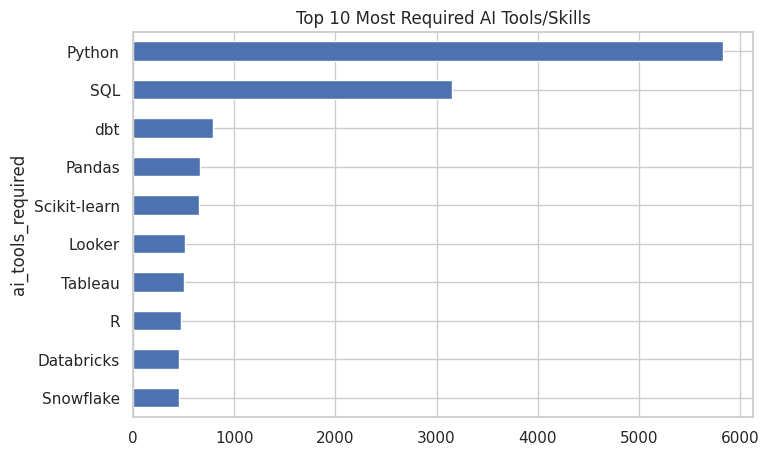

In [132]:
#Most In-Demand Skills  using Basic Text Analysis
from collections import Counter
tools = df_clean['ai_tools_required'].str.split(',').explode().str.strip()
top_tools = tools.value_counts().head(10)
top_tools.plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Most Required AI Tools/Skills')
plt.gca().invert_yaxis()
plt.show()

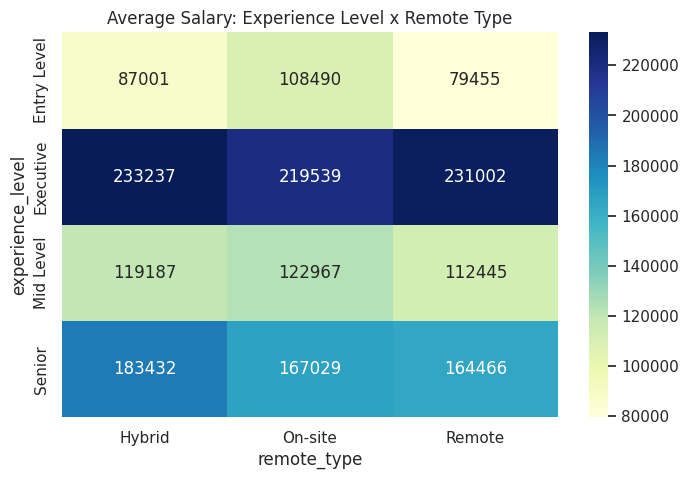

In [133]:
#The intersection of experience and the type of work
pivot = df_clean.pivot_table(values='salary_usd', index='experience_level', columns='remote_type', aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Salary: Experience Level x Remote Type')
plt.show()

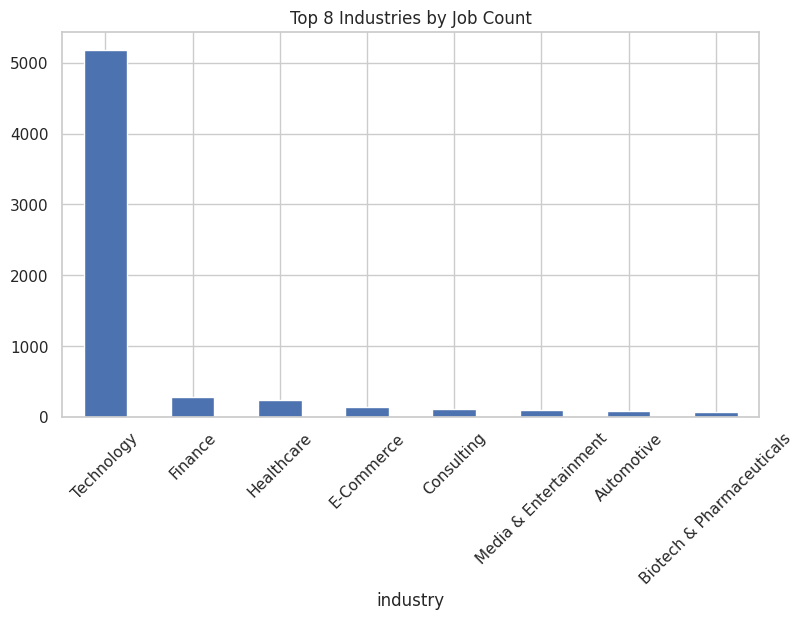

In [134]:
top_industries = df_clean['industry'].value_counts().head(8)
top_industries.plot(kind='bar', figsize=(9,5))
plt.title('Top 8 Industries by Job Count')
plt.xticks(rotation=45)
plt.show()

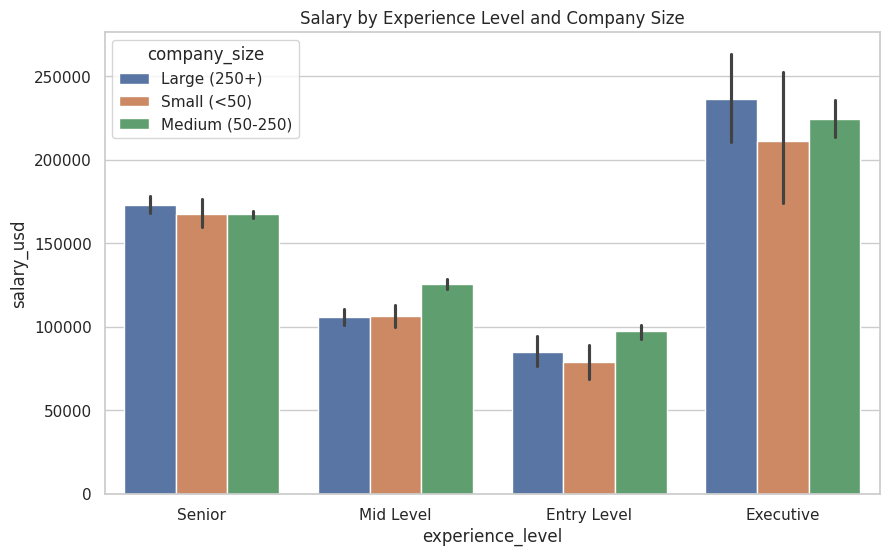

In [136]:
#Company Size × Salary × Experience Level
plt.figure(figsize=(10,6))
sns.barplot(data=df_clean, x='experience_level', y='salary_usd', hue='company_size')
plt.title('Salary by Experience Level and Company Size')
plt.show()